# 05. Robustness Checks & Selection Bias Appendix

**Input**: `accepted_modeling.parquet` (Notebook 02), `accepted_with_current.parquet` and `rejected_cleaned.parquet` (Notebook 01)

**Goal**: Verify that the AIPW ATE from Notebook 04 is stable across different sample restrictions and specification choices, and characterise the selection process that produces the approved-loan sample.

**Robustness checks**:
1. **36-month loans only**
2. **2014–2015 vintage only**
3. **Purpose subsamples**
4. **'Current' loans included** (lower-bound check)
5. **High-rate threshold sensitivity** (25th–75th percentile cutoffs)

**Selection bias appendix**:
- Approved vs. rejected covariate distributions
- Approval model (P(approved | observables))
- Interpretation: *pricing only on approved loans may understate the role of selection*

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

sns.set_theme(style='whitegrid', font_scale=1.1)

os.chdir('C:/Users/David Cho/OneDrive/Desktop/Projects/All Lending Club Loan')

In [3]:
DATA_DIR  = './data'

mdf = pd.read_parquet(f'{DATA_DIR}/accepted_modeling.parquet')
with open(f'{DATA_DIR}/meta.json') as f:
    meta = json.load(f)
COVARIATES = [c for c in meta['COVARIATES'] if c in mdf.columns]
COVARIATES2 = [col for col in COVARIATES if col != 'subgrade_num']

print(f'Modeling dataset: {mdf.shape}')
print(f'Default rate    : {mdf["default"].mean():.4f}')

Modeling dataset: (1025917, 29)
Default rate    : 0.2009


## AIPW Helper Function

In [26]:
def aipw_ate(y, T, X, n_splits=5, seed=42):
    """Cross-fitted AIPW ATE estimator.

    Parameters
    ----------
    y : (n,) binary outcome
    T : (n,) binary treatment
    X : (n, p) pre-treatment covariates

    Returns
    -------
    ate, se, ci_lo, ci_hi
    """
    cv    = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    ps    = np.zeros(len(y))
    mu1   = np.zeros(len(y))
    mu0   = np.zeros(len(y))

    ps_lr = LogisticRegression(C=0.5, max_iter=500)

    out_xgb = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    )

    for tr, te in cv.split(X, T):
        ps_lr.fit(X[tr], T[tr])
        ps[te] = np.clip(ps_lr.predict_proba(X[te])[:, 1], 0.01, 0.99)
        for arm, store in [(1, mu1), (0, mu0)]:
            idx = T[tr] == arm
            m   = out_xgb
            if idx.sum() > 10:
                m.fit(X[tr][idx], y[tr][idx])
                store[te] = m.predict_proba(X[te])[:, 1]
            else:
                store[te] = (y[tr][idx].mean() if idx.sum() > 0 else 0.0)

    psi   = (mu1 - mu0) + T*(y - mu1)/ps - (1 - T)*(y - mu0)/(1 - ps)
    ate   = psi.mean()
    se    = psi.std() / np.sqrt(len(psi))
    return ate, se, ate - 1.96*se, ate + 1.96*se


def get_X(data, cols=None):
    cols = cols or COVARIATES2
    return data[[c for c in cols if c in data.columns]].fillna(0).astype(float).values

## Baseline AIPW (reference)

In [27]:
base = mdf.dropna(subset=COVARIATES2 + ['default', 'high_rate'])
print(f'Baseline n = {len(base):,}')

ate_base, se_base, ci_lo_base, ci_hi_base = aipw_ate(
    base['default'].values, base['high_rate'].values, get_X(base)
)
print(f'Baseline AIPW ATE : {ate_base*100:+.4f} pp  [{ci_lo_base*100:.4f}, {ci_hi_base*100:.4f}]')

Baseline n = 1,025,917
Baseline AIPW ATE : +2.0836 pp  [1.9254, 2.2419]


---
## Robustness 1 — 36-Month Loans Only

In [30]:
sub36 = mdf[mdf['term_months_encoded'] == 0].copy()
# Recompute treatment within the 36-month subsample
med36 = sub36.groupby('grade_num')['int_rate'].median()
sub36['high_rate_36'] = (sub36['int_rate'] > sub36['grade_num'].map(med36)).astype(int)
sub36 = sub36.dropna(subset=COVARIATES2 + ['default', 'high_rate_36'])

print(f'36-month: n={len(sub36):,}  default_rate={sub36["default"].mean():.4f}')
ate_36, se_36, ci_lo_36, ci_hi_36 = aipw_ate(
    sub36['default'].values, sub36['high_rate_36'].values, get_X(sub36)
)
print(f'AIPW ATE : {ate_36*100:+.4f} pp  [{ci_lo_36*100:.4f}, {ci_hi_36*100:.4f}]')

36-month: n=777,875  default_rate=0.1579
AIPW ATE : +2.2608 pp  [2.0899, 2.4317]


---
## Robustness 2 — 2014–2015 Vintage Only

In [35]:
sub_yr = mdf[mdf['issue_year_encoded'].isin([1, 2])].dropna(subset=COVARIATES2 + ['default', 'high_rate'])
print(f'2014-2015: n={len(sub_yr):,}  default_rate={sub_yr["default"].mean():.4f}')
ate_yr, se_yr, ci_lo_yr, ci_hi_yr = aipw_ate(
    sub_yr['default'].values, sub_yr['high_rate'].values, get_X(sub_yr)
)
print(f'AIPW ATE : {ate_yr*100:+.4f} pp  [{ci_lo_yr*100:.4f}, {ci_hi_yr*100:.4f}]')

2014-2015: n=598,375  default_rate=0.1954
AIPW ATE : +2.0372 pp  [1.7941, 2.2804]


---
## Robustness 3 — Purpose Subsamples

In [41]:
purpose_results = {}
cols = [
    'purpose_home_asset',
    'purpose_medical',
    'purpose_other',
    'purpose_planned_purchase',
    'purpose_small_business'
]

if dc_col in mdf.columns:
    for label, mask in [
        ('debt_purposes', (mdf[cols]==0).all(axis=1)),
        ('other_purposes', (mdf[cols]==1).any(axis=1))
    ]:
        sub_p = mdf[mask].dropna(subset=COVARIATES + ['default', 'high_rate'])
        print(f'{label:<25}  n={len(sub_p):,}  default={sub_p["default"].mean():.4f}')
        ate_p, se_p, ci_lo_p, ci_hi_p = aipw_ate(
            sub_p['default'].values, sub_p['high_rate'].values, get_X(sub_p)
        )
        purpose_results[label] = dict(n=len(sub_p), ate=ate_p, se=se_p, ci_lo=ci_lo_p, ci_hi=ci_hi_p)
        print(f'  ATE = {ate_p*100:+.4f} pp  [{ci_lo_p*100:.4f}, {ci_hi_p*100:.4f}]')

debt_purposes              n=842,797  default=0.2009
  ATE = +2.1417 pp  [1.9661, 2.3173]
other_purposes             n=183,120  default=0.2011
  ATE = +1.7391 pp  [1.3728, 2.1055]


---
## Robustness 4 — High-Rate Threshold Sensitivity

In [49]:
QUANTILES    = [0.25, 0.33, 0.50, 0.67, 0.75]
thresh_rows  = []
complete_mdf = mdf.dropna(subset=COVARIATES2 + ['default', 'int_rate', 'grade_num'])

for q in QUANTILES:
    sub_q = complete_mdf.copy()
    gq = sub_q.groupby('grade_num')['int_rate'].quantile(q)
    sub_q['hr_q'] = (sub_q['int_rate'] > sub_q['grade_num'].map(gq)).astype(int)
    tf = sub_q['hr_q'].mean()
    print(f'q={q:.2f}  ({tf:.1%} treated)  computing AIPW...')
    ate_q, se_q, ci_lo_q, ci_hi_q = aipw_ate(
        sub_q['default'].values, sub_q['hr_q'].values, get_X(sub_q)
    )
    thresh_rows.append(dict(quantile=q, pct_treated=tf,
                             ate=ate_q, se=se_q, ci_lo=ci_lo_q, ci_hi=ci_hi_q))
    print(f'  ATE = {ate_q*100:+.4f} pp  [{ci_lo_q*100:.4f}, {ci_hi_q*100:.4f}]')

thresh_df = pd.DataFrame(thresh_rows)
print(thresh_df.round(4).to_string(index=False))

q=0.25  (72.2% treated)  computing AIPW...
  ATE = +2.1052 pp  [1.9362, 2.2742]
q=0.33  (62.0% treated)  computing AIPW...
  ATE = +2.1675 pp  [2.0114, 2.3237]
q=0.50  (46.9% treated)  computing AIPW...
  ATE = +2.0836 pp  [1.9254, 2.2419]
q=0.67  (32.2% treated)  computing AIPW...
  ATE = +1.9208 pp  [1.7396, 2.1020]
q=0.75  (22.2% treated)  computing AIPW...
  ATE = +1.4665 pp  [1.1984, 1.7346]
 quantile  pct_treated    ate     se  ci_lo  ci_hi
     0.25       0.7223 0.0211 0.0009 0.0194 0.0227
     0.33       0.6199 0.0217 0.0008 0.0201 0.0232
     0.50       0.4694 0.0208 0.0008 0.0193 0.0224
     0.67       0.3216 0.0192 0.0009 0.0174 0.0210
     0.75       0.2221 0.0147 0.0014 0.0120 0.0173


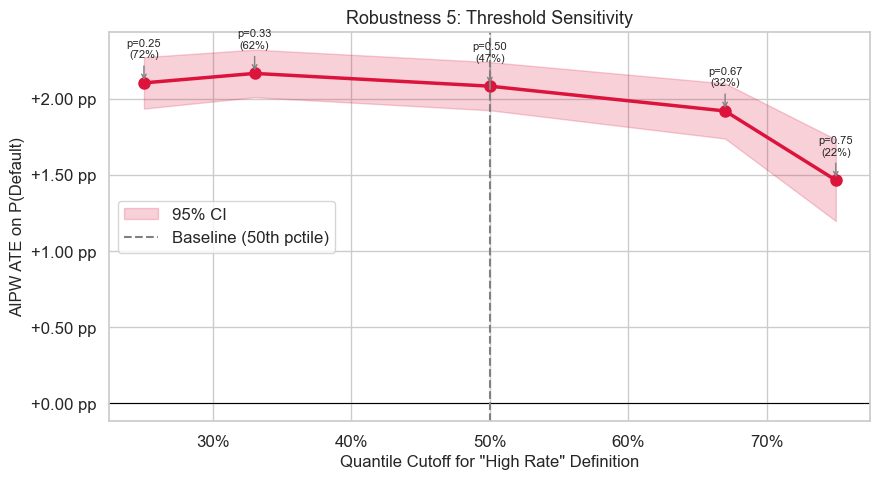

In [51]:
MODEL_DIR = './model'

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresh_df['quantile'], thresh_df['ate']*100,
        color='crimson', linewidth=2.5, marker='o', markersize=8)
ax.fill_between(thresh_df['quantile'],
                thresh_df['ci_lo']*100, thresh_df['ci_hi']*100,
                alpha=0.2, color='crimson', label='95% CI')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0.50, color='grey', linestyle='--', linewidth=1.5, label='Baseline (50th pctile)')
for _, row in thresh_df.iterrows():
    ax.annotate(f'p={row["quantile"]:.2f}\n({row["pct_treated"]:.0%})',
                xy=(row['quantile'], row['ate']*100),
                xytext=(0, 18), textcoords='offset points', ha='center', fontsize=8,
                arrowprops=dict(arrowstyle='->', color='grey'))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:+.2f} pp'))
ax.set_xlabel('Quantile Cutoff for "High Rate" Definition', fontsize=12)
ax.set_ylabel('AIPW ATE on P(Default)', fontsize=12)
ax.set_title('Robustness 5: Threshold Sensitivity', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/fig22_threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

The monotonic decline in estimated effects as the treatment threshold increases provides evidence of treatment effect heterogeneity. In particular, the marginal impact of interest rates appears to be stronger among relatively lower-risk borrowers and attenuates for higher-risk segments, consistent with diminishing sensitivity at higher levels of risk.

---
## Robustness Plot — All Specifications

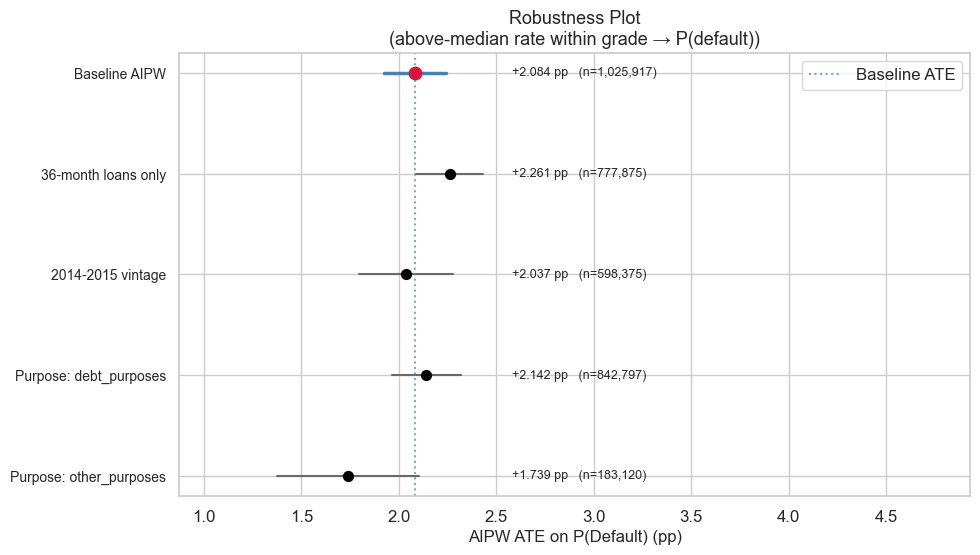

          Specification  ATE_pp  CI_lo  CI_hi       n
          Baseline AIPW  2.0836 1.9254 2.2419 1025917
    36-month loans only  2.2608 2.0899 2.4317  777875
      2014-2015 vintage  2.0372 1.7941 2.2804  598375
 Purpose: debt_purposes  2.1417 1.9661 2.3173  842797
Purpose: other_purposes  1.7391 1.3728 2.1055  183120


In [54]:
forest_rows = [
    ('Baseline AIPW',        ate_base*100, ci_lo_base*100, ci_hi_base*100, len(base)),
    ('36-month loans only',  ate_36*100,   ci_lo_36*100,   ci_hi_36*100,   len(sub36)),
    ('2014-2015 vintage',    ate_yr*100,   ci_lo_yr*100,   ci_hi_yr*100,   len(sub_yr)),
]
for purp, res in purpose_results.items():
    forest_rows.append((f'Purpose: {purp[:22]}',
                        res['ate']*100, res['ci_lo']*100, res['ci_hi']*100, res['n']))

forest_df = pd.DataFrame(forest_rows, columns=['Specification','ATE_pp','CI_lo','CI_hi','n'])

fig, ax = plt.subplots(figsize=(10, len(forest_df)*0.75 + 2))
y_pos = np.arange(len(forest_df))[::-1]

for i, (y, (_, row)) in enumerate(zip(y_pos, forest_df.iterrows())):
    color = 'steelblue' if i == 0 else 'dimgrey'
    lw    = 2.5 if i == 0 else 1.5
    ax.plot([row['CI_lo'], row['CI_hi']], [y, y], color=color, linewidth=lw)
    ax.scatter(row['ATE_pp'], y,
               color='crimson' if i == 0 else 'black', s=80 if i == 0 else 50, zorder=5)
    ax.text(forest_df['CI_hi'].max() + 0.15, y,
            f'{row["ATE_pp"]:+.3f} pp   (n={int(row["n"]):,})',
            va='center', fontsize=9)

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(ate_base*100, color='steelblue', linewidth=1.5, linestyle=':', alpha=0.7, label='Baseline ATE')
ax.set_yticks(y_pos)
ax.set_yticklabels(forest_df['Specification'], fontsize=10)
ax.set_xlabel('AIPW ATE on P(Default) (pp)', fontsize=12)
ax.set_title('Robustness Plot\n(above-median rate within grade → P(default))', fontsize=13)
ax.legend()
ax.set_xlim(forest_df['CI_lo'].min() - 0.5, forest_df['CI_hi'].max() + 2.5)

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/fig23_robustness.png', dpi=150, bbox_inches='tight')
plt.show()

print(forest_df.round(4).to_string(index=False))

### Robustness Summary

The estimated treatment effect remains stable across multiple subsamples, including different loan terms, issuance periods, and loan purposes. This consistency suggests that the positive relationship between higher interest rates and default is robust and not driven by specific sample composition. The robustness of the estimated effects across specifications strengthens the causal interpretation.

---
# Appendix: Selection Bias

In [61]:
rej = pd.read_parquet(f'{DATA_DIR}/rejected_cleaned.parquet')
print(f'Rejected (2013-2016): {rej.shape}')

Rejected (2013-2016): (10323895, 14)


In [58]:
rej.head(3)

,Amount Requested,Application Date,Loan Title,Risk_Score,Debt-To-Income Ratio,Zip Code,State,Employment Length,Policy Code,issue_year,dti,emp_length_num,loan_amnt,fico_mid
0,1000.0,2016-04-01,other,NaN,2.69%,331xx,FL,< 1 year,0.0,2016,2.69,0.0,1000.0,NaN
1,4000.0,2016-04-01,debt_consolidation,NaN,28.26%,834xx,ID,< 1 year,0.0,2016,28.26,0.0,4000.0,NaN
2,5000.0,2016-04-01,moving,NaN,-1%,648xx,MO,Unknown,0.0,2016,-1.00,-1.0,5000.0,NaN


In [62]:
acc = pd.read_parquet(f'{DATA_DIR}/accepted_cleaned.parquet')
print(f'Accepted (2013-2016): {acc.shape}')

Accepted (2013-2016): (1025982, 33)


In [64]:
acc.head(3)

,id,loan_amnt,funded_amnt,term,int_rate,grade,sub_grade,emp_length,home_ownership,annual_inc,...,revol_bal,revol_util,total_acc,application_type,issue_year,term_months,emp_length_num,fico_mid,ever_delinq,annual_inc_cap
0,68407277,3600.0,3600.0,36 months,13.99,C,C4,10+ years,MORTGAGE,55000.0,...,2765.0,29.7,13.0,Individual,2015,36,10.0,677.0,1,55000.0
1,68355089,24700.0,24700.0,36 months,11.99,C,C1,10+ years,MORTGAGE,65000.0,...,21470.0,19.2,38.0,Individual,2015,36,10.0,717.0,1,65000.0
2,68341763,20000.0,20000.0,60 months,10.78,B,B4,10+ years,MORTGAGE,63000.0,...,7869.0,56.2,18.0,Joint App,2015,60,10.0,697.0,0,63000.0


Combined: (4971027, 6)  approval_rate=0.2064


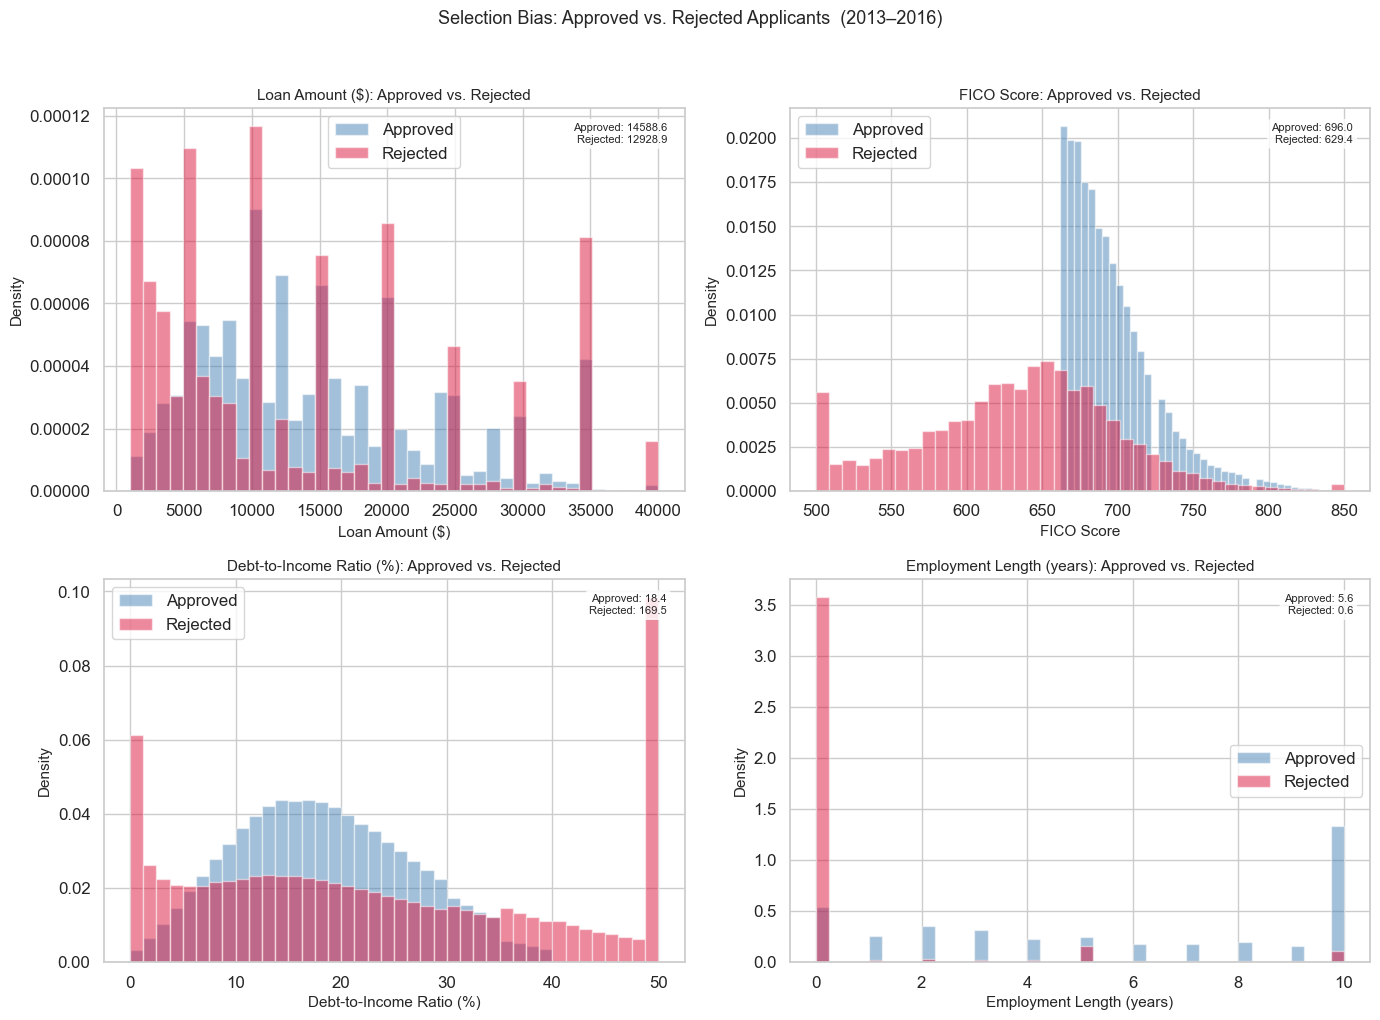

In [69]:
acc_sub = acc[['loan_amnt','fico_mid','dti','emp_length_num','issue_year']].copy()
acc_sub['approved'] = 1

rej_sub = rej[['loan_amnt','fico_mid','dti','emp_length_num','issue_year']].copy()
rej_sub['approved'] = 0

combined = pd.concat([acc_sub, rej_sub], ignore_index=True)
combined = combined[combined['issue_year'].between(2013, 2016)].dropna()

print(f'Combined: {combined.shape}  approval_rate={combined["approved"].mean():.4f}')

# Covariate distributions: approved vs. rejected
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pairs = [
    ('loan_amnt',      'Loan Amount ($)',           0,   40000),
    ('fico_mid',       'FICO Score',               500,    850),
    ('dti',            'Debt-to-Income Ratio (%)',   0,     50),
    ('emp_length_num', 'Employment Length (years)',  0,     10)
]
for ax, (var, label, lo, hi) in zip(axes.flatten(), pairs):
    for status, color, lbl in [(1,'steelblue','Approved'),(0,'crimson','Rejected')]:
        vals = combined[combined['approved']==status][var].dropna().clip(lo, hi)
        ax.hist(vals, bins=40, alpha=0.5, color=color, density=True, label=lbl)
    m_a = combined[combined['approved']==1][var].dropna().mean()
    m_r = combined[combined['approved']==0][var].dropna().mean()
    ax.text(0.97, 0.96, f'Approved: {m_a:.1f}\nRejected: {m_r:.1f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_xlabel(label, fontsize=11); ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{label}: Approved vs. Rejected', fontsize=11); ax.legend()

plt.suptitle('Selection Bias: Approved vs. Rejected Applicants  (2013–2016)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/fig24_selection_bias.png', dpi=150, bbox_inches='tight')
plt.show()

1. **Loan Amount**: Approval is not monotonic in loan size; instead, certain commonly requested amounts are disproportionately rejected, suggesting interaction with internal underwriting rules or applicant self-selection at standard loan increments.

2. **FICO Score**: FICO score appears to act as a hard threshold (660<=) in the approval process, indicating a rule-based screening mechanism rather than a smooth decision boundary.

3. **DTI**: Both extremely low and extremely high DTI values are associated with rejection, while mid-range DTI borrowers are evaluated more flexibly based on other characteristics.

4. **Employment Length**: Employment length, particularly having no employment history, is a strong negative signal for approval and likely reflects borrower repayment capacity.

In [74]:
APPROVAL_X = ['loan_amnt', 'fico_mid', 'dti', 'emp_length_num']
app_df = combined[APPROVAL_X + ['approved']].dropna()
X_app  = app_df[APPROVAL_X].values
y_app  = app_df['approved'].values

app_pipe = Pipeline([('sc', StandardScaler()),
                     ('lr', LogisticRegression(C=1.0, max_iter=300))])
cv_app   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
p_app    = cross_val_predict(app_pipe, X_app, y_app, cv=cv_app, method='predict_proba')[:, 1]

auc_app = roc_auc_score(y_app, p_app)
print(f'Approval model CV AUC: {auc_app:.4f}')

app_pipe.fit(X_app, y_app)
coef_series = (
    pd.Series(app_pipe.named_steps['lr'].coef_[0], index=APPROVAL_X)
    .sort_values(ascending=False)
)
print('\nApproval model log-odds (standardized inputs):')
print(coef_series.round(4))
print()

Approval model CV AUC: 0.9215

Approval model log-odds (standardized inputs):
fico_mid           1.4953
emp_length_num     1.1807
loan_amnt         -0.1966
dti              -85.1076
dtype: float64



### Selection Bias Summary

High model AUC (0.92) shows that approval is highly predictable based on observed features. In standardized terms, *FICO score* is the strongest positive predictor of approval, followed by *employment length*, while *DTI* has a strong negative effect, and *loan amount* has a modest negative effect, suggesting that lenders prioritize creditworthiness and repayment capacity over loan size.

The approval model confirms that lending decisions are not purely based on smooth risk scoring, but instead reflect a combination of threshold-based and nonlinear rules. In particular, FICO score and employment length act as primary screening variables, while DTI and loan amount exhibit nonlinear effects, with rejection concentrated at extreme values or specific discrete points.

Our causal estimates are therefore identified on a selected subset of relatively stable and rule-compliant borrowers, rather than the full applicant population. As a result, causal estimates based on approved loans likely understate the true impact of interest rates in the broader applicant population.